# 06 — Treinamento do MLP

**Projeto:** Medical Triage MLOps

## Objetivo

Treinar o primeiro modelo próprio do projeto para classificar os abstracts em:

```text
normal
atenção
urgente
```

O pipeline será:

```text
medical_abstract
      ↓
TF-IDF
      ↓
MLPClassifier
      ↓
normal / atenção / urgente
```

A validação será usada para avaliar o baseline antes de consultar o conjunto de teste.

> **Importante:** os targets utilizados são pseudo-rótulos produzidos a partir do BioBERT e da regra de threshold definida nos notebooks anteriores. Portanto, as métricas deste notebook medem a capacidade do MLP de aprender esses pseudo-rótulos, e não validade clínica real.

## 1. Dependências

Caso ainda não estejam instaladas:

```bash
uv add scikit-learn joblib matplotlib pandas numpy
uv sync
```

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.20,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

RANDOM_STATE = 42

CLASS_ORDER = ["normal", "atenção", "urgente"]

COLORS = {
    "normal": "#16A085",
    "atenção": "#F4B942",
    "urgente": "#D63031",
}

## 2. Carregamento dos splits

In [2]:
def locate_project_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in [current, current.parent, current.parent.parent]:
        expected = candidate / "data" / "processed" / "splits" / "train.csv"
        if expected.exists():
            return candidate

    raise FileNotFoundError(
        "Não encontrei data/processed/splits/train.csv. "
        "Execute primeiro o notebook 05_data_split.ipynb."
    )


PROJECT_ROOT = locate_project_root()
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "docs" / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(SPLITS_DIR / "train.csv")
validation_df = pd.read_csv(SPLITS_DIR / "validation.csv")
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

print(f"Treino:    {len(train_df):,}")
print(f"Validação: {len(validation_df):,}")
print(f"Teste:     {len(test_df):,}")

Treino:    7,858
Validação: 1,684
Teste:     1,685


### Conferência rápida dos dados

In [3]:
display(
    pd.DataFrame(
        {
            "conjunto": ["Treino", "Validação", "Teste"],
            "registros": [
                len(train_df),
                len(validation_df),
                len(test_df),
            ],
            "textos_únicos": [
                train_df["medical_abstract"].nunique(),
                validation_df["medical_abstract"].nunique(),
                test_df["medical_abstract"].nunique(),
            ],
            "classes": [
                train_df["triage_level"].nunique(),
                validation_df["triage_level"].nunique(),
                test_df["triage_level"].nunique(),
            ],
        }
    )
)

,conjunto,registros,textos_únicos,classes
0,Treino,7858,7858,3
1,Validação,1684,1684,3
2,Teste,1685,1685,3


## 3. Variáveis do modelo

O modelo usa exclusivamente:

```text
X = medical_abstract
y = triage_level
```

Os scores do BioBERT não entram como features.

In [4]:
X_train = train_df["medical_abstract"].astype(str)
y_train = train_df["triage_level"].astype(str)

X_validation = validation_df["medical_abstract"].astype(str)
y_validation = validation_df["triage_level"].astype(str)

X_test = test_df["medical_abstract"].astype(str)
y_test = test_df["triage_level"].astype(str)

print("Classes no treino:")
print(y_train.value_counts().reindex(CLASS_ORDER))

Classes no treino:
triage_level
normal     3499
atenção    3411
urgente     948
Name: count, dtype: int64


## 4. Pipeline TF-IDF + MLP

### TF-IDF

A representação TF-IDF transforma os textos em vetores numéricos ponderando termos conforme sua frequência no documento e no corpus.

Configuração inicial:

- unigramas e bigramas;
- remoção de stopwords em inglês;
- termos presentes em pelo menos 2 documentos;
- máximo de 5.000 features;
- `sublinear_tf=True`.

### MLP

Usaremos um MLP pequeno como baseline:

```text
entrada TF-IDF
     ↓
64 neurônios
     ↓
3 classes
```

O objetivo neste momento é obter um modelo simples, leve e fácil de comparar com os modelos dos colegas.

In [5]:
pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=5_000,
                sublinear_tf=True,
            ),
        ),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(64,),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size="auto",
                learning_rate_init=1e-3,
                max_iter=200,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=12,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

display(pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.95
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e.

## 5. Treinamento

In [6]:
training_start = time.perf_counter()

pipeline.fit(
    X_train,
    y_train,
)

training_time = time.perf_counter() - training_start

mlp = pipeline.named_steps["mlp"]
tfidf = pipeline.named_steps["tfidf"]

print(f"Tempo de treinamento: {training_time:.2f} segundos")
print(f"Épocas executadas: {mlp.n_iter_}")
print(f"Features TF-IDF: {len(tfidf.get_feature_names_out()):,}")

Tempo de treinamento: 7.78 segundos
Épocas executadas: 24
Features TF-IDF: 5,000


### Curva de perda

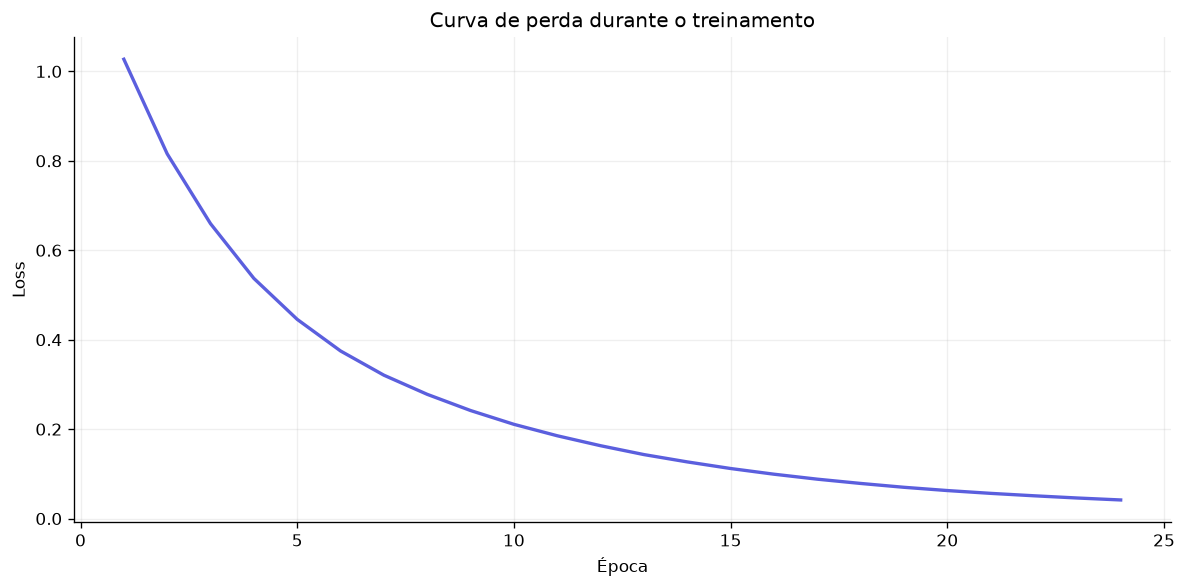

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(1, len(mlp.loss_curve_) + 1),
    mlp.loss_curve_,
    linewidth=2,
    color="#5B5FDE",
)

ax.set_title("Curva de perda durante o treinamento")
ax.set_xlabel("Época")
ax.set_ylabel("Loss")

plt.tight_layout()
plt.show()

## 6. Função de avaliação

Como a classe `urgente` é menor, não vamos olhar apenas para accuracy.

As métricas principais são:

- accuracy;
- balanced accuracy;
- macro precision;
- macro recall;
- macro F1-score;
- métricas por classe.

In [8]:
def evaluate_model(
    model,
    X,
    y_true,
    dataset_name: str,
):
    y_pred = model.predict(X)

    metrics = {
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
    }

    return metrics, y_pred

## 7. Avaliação no conjunto de validação

In [9]:
validation_metrics, y_validation_pred = evaluate_model(
    pipeline,
    X_validation,
    y_validation,
    "validation",
)

display(
    pd.DataFrame([validation_metrics])
)

,dataset,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.7637,0.6990,0.7502,0.6990,0.7180


### Relatório por classe

In [10]:
validation_report = classification_report(
    y_validation,
    y_validation_pred,
    labels=CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)

validation_report_df = (
    pd.DataFrame(validation_report)
    .T
)

display(validation_report_df)

,precision,recall,f1-score,support
normal,0.8265,0.8320,0.8292,750.0000
atenção,0.7128,0.7674,0.7391,731.0000
urgente,0.7113,0.4975,0.5855,203.0000
accuracy,0.7637,0.7637,0.7637,0.7637
macro avg,0.7502,0.6990,0.7180,"1,684.0000"
weighted avg,0.7633,0.7637,0.7607,"1,684.0000"


### Matriz de confusão — validação

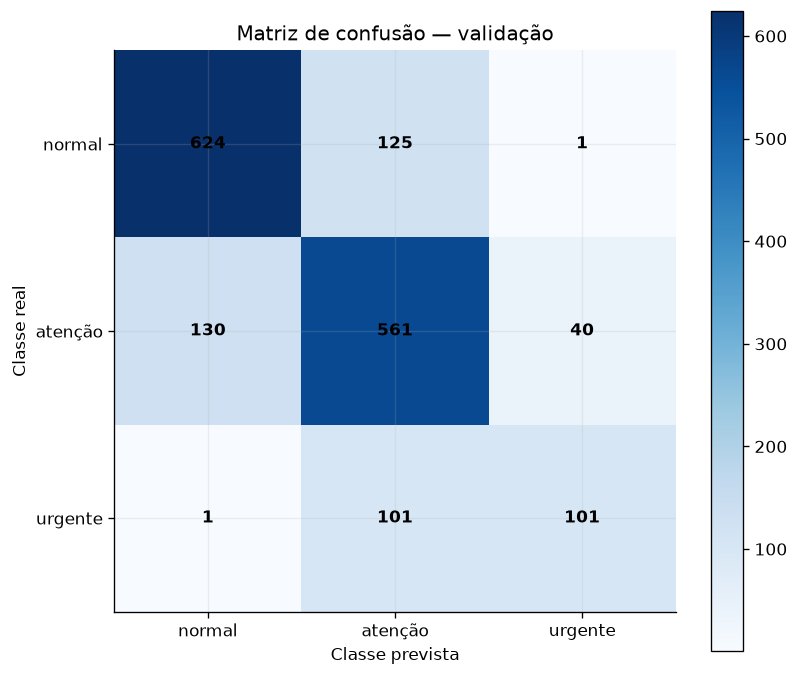

In [11]:
validation_cm = confusion_matrix(
    y_validation,
    y_validation_pred,
    labels=CLASS_ORDER,
)

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    validation_cm,
    cmap="Blues",
)

ax.set_title("Matriz de confusão — validação")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER)
ax.set_yticklabels(CLASS_ORDER)

for row in range(len(CLASS_ORDER)):
    for col in range(len(CLASS_ORDER)):
        ax.text(
            col,
            row,
            validation_cm[row, col],
            ha="center",
            va="center",
            fontweight="bold",
        )

fig.colorbar(image, ax=ax)

plt.tight_layout()
plt.show()

## 8. Recall da classe urgente

Para o contexto do projeto, é especialmente importante observar quantos casos pseudo-rotulados como `urgente` o modelo consegue recuperar.

In [12]:
urgent_row = validation_report_df.loc["urgente"]

urgent_validation = pd.DataFrame(
    {
        "métrica": [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
        "valor": [
            urgent_row["precision"],
            urgent_row["recall"],
            urgent_row["f1-score"],
            urgent_row["support"],
        ],
    }
)

display(urgent_validation)

,métrica,valor
0,precision,0.7113
1,recall,0.4975
2,f1-score,0.5855
3,support,203.0000


## 9. Decisão antes do teste

O conjunto de teste deve funcionar como avaliação final.

Neste notebook, depois de observar a validação, vamos manter **a mesma configuração** do pipeline e fazer uma única avaliação no teste.

Se você decidir alterar arquitetura, `max_features`, `alpha` ou outros hiperparâmetros depois de olhar a validação, faça a alteração **antes** de executar a seção de teste.

## 10. Avaliação final no teste

In [13]:
test_metrics, y_test_pred = evaluate_model(
    pipeline,
    X_test,
    y_test,
    "test",
)

display(
    pd.DataFrame([test_metrics])
)

,dataset,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
0,test,0.7763,0.7314,0.7725,0.7314,0.7480


### Relatório por classe — teste

In [14]:
test_report = classification_report(
    y_test,
    y_test_pred,
    labels=CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)

test_report_df = pd.DataFrame(test_report).T

display(test_report_df)

,precision,recall,f1-score,support
normal,0.8402,0.8123,0.8260,751.0000
atenção,0.7225,0.7907,0.7551,731.0000
urgente,0.7547,0.5911,0.6630,203.0000
accuracy,0.7763,0.7763,0.7763,0.7763
macro avg,0.7725,0.7314,0.7480,"1,685.0000"
weighted avg,0.7788,0.7763,0.7756,"1,685.0000"


### Matriz de confusão — teste

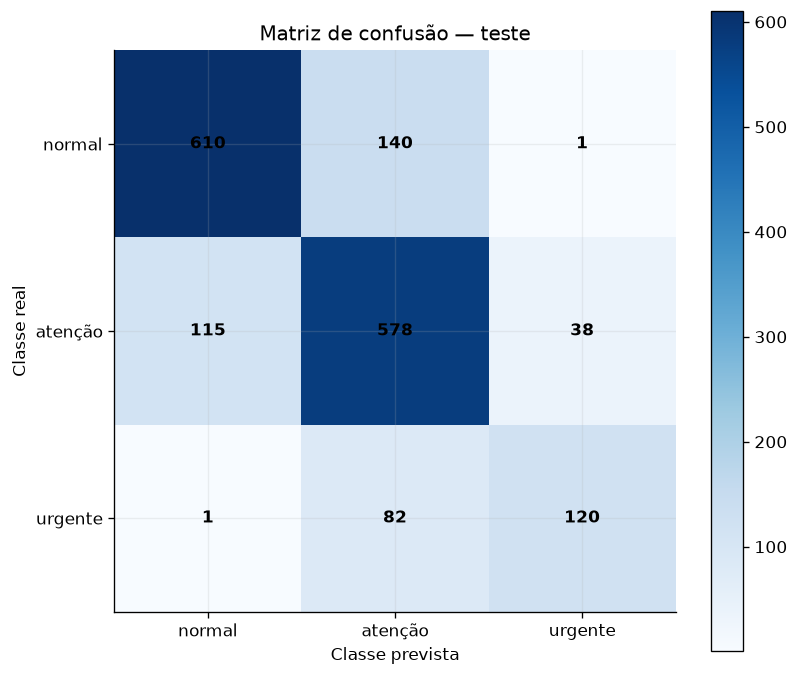

In [15]:
test_cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=CLASS_ORDER,
)

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    test_cm,
    cmap="Blues",
)

ax.set_title("Matriz de confusão — teste")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER)
ax.set_yticklabels(CLASS_ORDER)

for row in range(len(CLASS_ORDER)):
    for col in range(len(CLASS_ORDER)):
        ax.text(
            col,
            row,
            test_cm[row, col],
            ha="center",
            va="center",
            fontweight="bold",
        )

fig.colorbar(image, ax=ax)

plt.tight_layout()
plt.show()

## 11. Comparação validação x teste

In [16]:
metrics_comparison = pd.DataFrame(
    [
        validation_metrics,
        test_metrics,
    ]
).set_index("dataset")

display(metrics_comparison)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
dataset,,,,,
validation,0.7637,0.6990,0.7502,0.6990,0.7180
test,0.7763,0.7314,0.7725,0.7314,0.7480


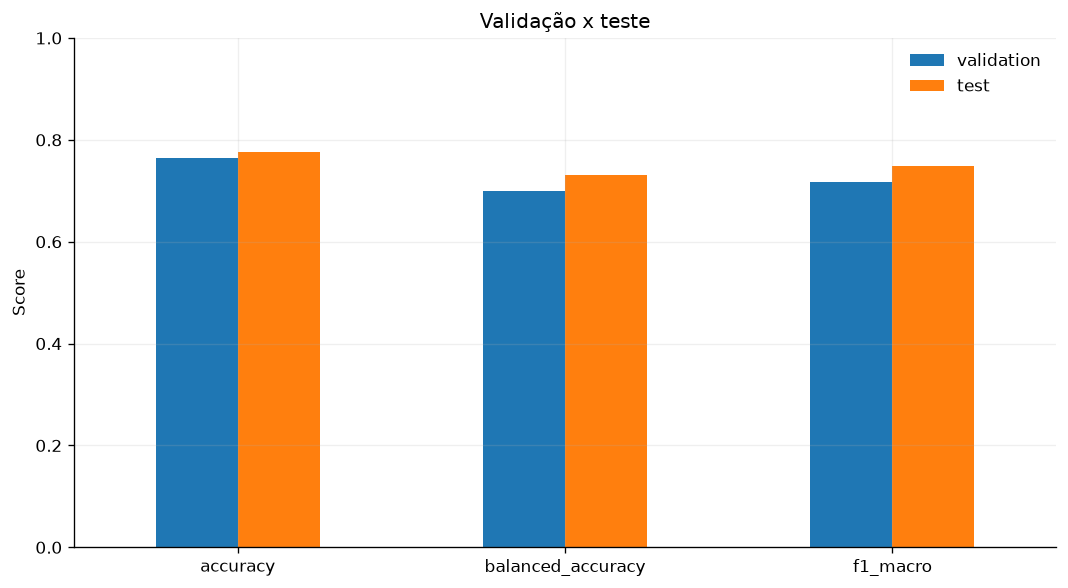

In [17]:
plot_metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
]

ax = (
    metrics_comparison[plot_metrics]
    .T
    .plot(
        kind="bar",
        figsize=(9, 5),
    )
)

ax.set_title("Validação x teste")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.legend(frameon=False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Latência de inferência

Além da qualidade do modelo, o desafio também envolve latência.

Aqui medimos a previsão **texto a texto**, incluindo:

```text
TF-IDF + MLP
```

Isso se aproxima mais da forma como a API fará uma requisição individual.

In [18]:
latencies_ms = []

for text in X_test:
    start = time.perf_counter()

    pipeline.predict([text])

    elapsed_ms = (
        time.perf_counter() - start
    ) * 1_000

    latencies_ms.append(elapsed_ms)

latency_metrics = {
    "latency_mean_ms": float(np.mean(latencies_ms)),
    "latency_median_ms": float(np.median(latencies_ms)),
    "latency_p95_ms": float(np.percentile(latencies_ms, 95)),
    "latency_max_ms": float(np.max(latencies_ms)),
}

display(
    pd.DataFrame(
        latency_metrics.items(),
        columns=["métrica", "valor_ms"],
    )
)

,métrica,valor_ms
0,latency_mean_ms,0.6337
1,latency_median_ms,0.6388
2,latency_p95_ms,0.8711
3,latency_max_ms,1.3409


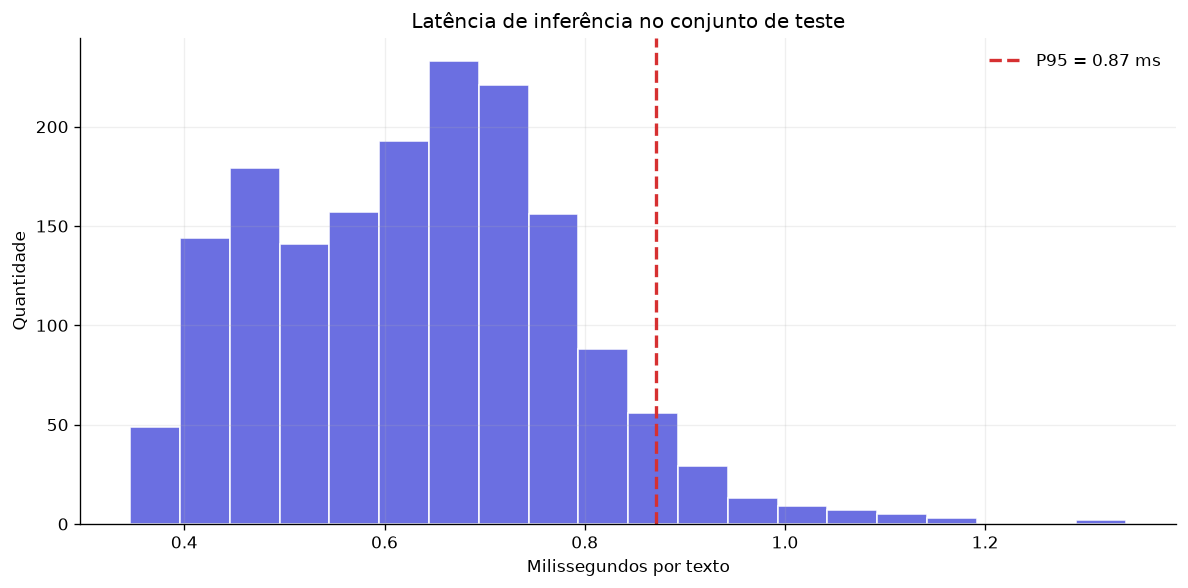

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    latencies_ms,
    bins=20,
    color="#5B5FDE",
    edgecolor="white",
    alpha=0.9,
)

ax.axvline(
    latency_metrics["latency_p95_ms"],
    color="#D63031",
    linestyle="--",
    linewidth=2,
    label=f"P95 = {latency_metrics['latency_p95_ms']:.2f} ms",
)

ax.set_title("Latência de inferência no conjunto de teste")
ax.set_xlabel("Milissegundos por texto")
ax.set_ylabel("Quantidade")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 13. Exemplos de predição

Essa etapa ajuda a verificar o formato que depois será usado pela FastAPI.

In [20]:
example_indices = list(
    range(min(5, len(test_df)))
)

examples = test_df.loc[
    example_indices,
    ["medical_abstract", "triage_level"],
].copy()

examples["prediction"] = pipeline.predict(
    examples["medical_abstract"]
)

probabilities = pipeline.predict_proba(
    examples["medical_abstract"]
)

for class_index, class_name in enumerate(pipeline.classes_):
    examples[f"prob_{class_name}"] = probabilities[:, class_index]

display(examples)

,medical_abstract,triage_level,prediction,prob_atenção,prob_normal,prob_urgente
0,Clinical and anatomical considerations for nonoperative therapy in tibial disease and the results of angioplasty. Fo...,atenção,atenção,0.7748,0.2222,0.0030
1,Cholesterol and coronary heart disease. Future directions. The importance of high serum cholesterol levels as a risk...,normal,normal,0.0006,0.9994,0.0000
2,Pseudo pre-excitation with concertina effect in idioventricular tachycardia. The concertina effect is a phenomenon w...,atenção,normal,0.0842,0.9100,0.0058
3,Proliferation and DNA ploidy in malignant breast tumors in relation to early oral contraceptive use and early aborti...,normal,normal,0.2643,0.7348,0.0009
4,Comparison of SPECT using technetium-99m agents and thallium-201 and PET for the assessment of myocardial perfusion ...,atenção,atenção,0.9865,0.0119,0.0016


## 14. Salvamento do modelo

Salvamos o **pipeline completo**, incluindo TF-IDF e MLP.

Isso permite fazer futuramente:

```python
model = joblib.load(...)
model.predict(["novo laudo"])
```

sem precisar carregar o vectorizer separadamente.

In [21]:
# Sufixo _v2: mlp_tfidf.joblib e o baseline v1 (720 amostras) e deve ser preservado.
MODEL_PATH = MODELS_DIR / "mlp_tfidf_v2.joblib"

joblib.dump(
    pipeline,
    MODEL_PATH,
)

model_size_mb = (
    MODEL_PATH.stat().st_size
    / 1024**2
)

print(f"Modelo salvo em: {MODEL_PATH}")
print(f"Tamanho: {model_size_mb:.2f} MB")

Modelo salvo em: C:\Users\erick\projetos\medical-triage-mlops\models\mlp_tfidf_v2.joblib
Tamanho: 7.53 MB


## 15. Salvamento das métricas

In [22]:
# Sufixo _v2: mlp_metrics.json guarda as metricas do baseline v1.
RESULTS_PATH = RESULTS_DIR / "mlp_metrics_v2.json"

results = {
    "model": "TF-IDF + MLPClassifier",
    "training_time_seconds": float(training_time),
    "training_iterations": int(mlp.n_iter_),
    "tfidf_features": int(len(tfidf.get_feature_names_out())),
    "model_size_mb": float(model_size_mb),
    "validation": {
        key: float(value)
        for key, value in validation_metrics.items()
        if key != "dataset"
    },
    "test": {
        key: float(value)
        for key, value in test_metrics.items()
        if key != "dataset"
    },
    "latency": latency_metrics,
    "configuration": {
        "hidden_layer_sizes": [64],
        "max_features": 5000,
        "ngram_range": [1, 2],
        "confidence_target_origin": "BioBERT pseudo-labeling + uncertainty zone",
        "random_state": RANDOM_STATE,
    },
}

with open(
    RESULTS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        results,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(f"Métricas salvas em: {RESULTS_PATH}")

Métricas salvas em: C:\Users\erick\projetos\medical-triage-mlops\docs\results\mlp_metrics_v2.json


## 16. Resumo automático do baseline

In [23]:
urgent_test_recall = (
    test_report_df.loc["urgente", "recall"]
)

summary = f'''
### Resultado do MLP baseline

- **Accuracy no teste:** {test_metrics["accuracy"]:.3f}
- **Balanced accuracy:** {test_metrics["balanced_accuracy"]:.3f}
- **Macro F1:** {test_metrics["f1_macro"]:.3f}
- **Macro recall:** {test_metrics["recall_macro"]:.3f}
- **Recall da classe urgente:** {urgent_test_recall:.3f}
- **Latência média:** {latency_metrics["latency_mean_ms"]:.2f} ms
- **Latência P95:** {latency_metrics["latency_p95_ms"]:.2f} ms
- **Tamanho do modelo:** {model_size_mb:.2f} MB
- **Tempo de treinamento:** {training_time:.2f} s
'''

display(Markdown(summary))


### Resultado do MLP baseline

- **Accuracy no teste:** 0.776
- **Balanced accuracy:** 0.731
- **Macro F1:** 0.748
- **Macro recall:** 0.731
- **Recall da classe urgente:** 0.591
- **Latência média:** 0.63 ms
- **Latência P95:** 0.87 ms
- **Tamanho do modelo:** 7.53 MB
- **Tempo de treinamento:** 7.78 s


## 17. Conclusão

Ao final deste notebook temos:

```text
models/
└── mlp_tfidf.joblib

docs/results/
└── mlp_metrics.json
```

O arquivo `.joblib` contém o pipeline completo:

```text
texto
  ↓
TF-IDF
  ↓
MLP
  ↓
normal / atenção / urgente
```

### Próximos passos

1. registrar as métricas do MLP para comparação com os modelos dos colegas;
2. decidir qual modelo seguirá para a aplicação;
3. integrar o modelo escolhido à FastAPI;
4. instrumentar a API com métricas do Prometheus;
5. criar o stack Prometheus + Grafana.

### Limitação

Como o MLP foi treinado com pseudo-rótulos, um bom resultado significa que ele conseguiu reproduzir o padrão desses rótulos. Isso não equivale a comprovar segurança ou validade clínica da triagem.